In [6]:
from DynamicModel import DynamicModel
from mod_stefan import StefanSolver
import logging
import numpy as np
import pandas as pd
from mod_rt import RayleighTaylorSolver
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
math_vars = {
    'high_rho': 3,
    'low_rho' : 1,
    'high_visc' : 0.001, #dynamic
    'low_visc' : 0.001,#0.0005,
    'wavelength' : 1,
    'grev': 1,
    'x_L' : 1,
    'y_L' : 4,
    'delta_h': 0.05,
    'timestep': 0.0035,
    'time_end': 8,
    'maxWidthCutOff': 0.01,
    'surface_tension': 1e-05
}

model = DynamicModel(math_vars)
solver = RayleighTaylorSolver(model)
model.set_solver(RayleighTaylorSolver)

model.set_nondim_consts(
    ref_l = 'x_L',
    ref_rho = 'high_rho',
    ref_grev = 'grev',
    ref_visc = 'low_visc',
    ref_visc_kin = lambda ref_visc, ref_rho: ref_visc/ref_rho, 
    ref_u = lambda ref_grev, ref_l: np.sqrt(ref_grev*ref_l),
    ref_surface_tension = lambda ref_l, ref_rho, ref_u, surface_tension: ref_rho*ref_l*np.pow(ref_u, 2)*surface_tension
)

#{} means it's in the mod_utils as a seperate class method, otherwise lambda
#model.calculate_nondim_nums(
    #atwood = {},
    #reynolds = {},
    #froude = {},
    #grash2 = lambda high_rho, low_rho, ref_grev, ref_l, ref_visc, ref_rho: ((high_rho - low_rho)/(high_rho + low_rho))*ref_grev*np.pow(ref_l, 3)/np.pow((ref_visc/ref_rho), 2),#Aglam^3/kin_visc^2
    #ren2 = lambda ref_grev, ref_l, ref_rho, ref_visc: (np.sqrt(np.pow(ref_l,3)*ref_grev)*ref_rho)/ref_visc
    #weber = lambda ref_rho, ref_l, ref_u, ref_surface_tension: ref_rho*ref_l*(np.pow(ref_u, 2))/ref_surface_tension,
    #eotvos = lambda high_rho, low_rho, ref_grev, ref_l, ref_surface_tension: (high_rho - low_rho)*ref_grev*np.pow(ref_l, 2)/ref_surface_tension
    #)

name_vars = {
    'x_dat': "X (m)",
    'y_dat': "Y (m)",
    'v_x': "Velocity[i] (m/s)",
    'v_y': "Velocity[j] (m/s)",
    'rel_v_x': "Relative Velocity[i] (m/s)",
    "rel_v_y": "Relative Velocity[j] (m/s)",
    'volFrac_high': "Volume Fraction of high_rho",
    'volFrac_low': "Volume Fraction of low_rho",
    'min_mixWidth': "minMixWidthEval",
    'max_mixWidth': "maxMixWidthEval",
    'massFlux': "Report: massImbalance_highRho (kg)",
    'mean_rho': "Density (kg/m^3)"
}   

In [ ]:
# %% ###############################################################
######################## Reynolds Number #########################
####################################################################
import scienceplots
dir_list = [
    #r'C:/Users/harsh/Desktop/pix',
    r"C:/Users/harsh/Desktop/pix/re300_at05",
    r'C:/Users/harsh/Desktop/pix/re1000_at05',
    r"C:/Users/harsh/Desktop/pix/re3000_at05_0045/details",
]
name = 'isosurface_table_'
name_append = '.csv'
#if reference time is different from the reference time initially set
ref_t = lambda atwood_num: np.sqrt(atwood_num)
#model.load_solution_data(dir, name, name_append, name_vars, ref_t= ref_t)
#model.calculate_stuff()
names = ['300', '1000', '3000']
h_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(path, name, name_append, name_vars, ref_t= ref_t)
    solver.calculate_stuff()
    cur_h_data = {}
    cur_h_data['name'] = names[idx]
    cur_h_data['timesteps'] = model.params['timesteps']
    cur_h_data.update(model.analysis_data)
    h_data.append(cur_h_data)
#----------------------------------------------------
dns_df = pd.read_csv(
    r'C:\Users\harsh\Desktop\pix\RT_evolution\dns_compare_data\2D_Single-Mode_At0.5_Re3000_A0.05.csv'
)
#----------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle
with plt.style.context('science-modern'):
    plt.style.use(['high-contrast'])
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    ls_cycler = cycle(['-', '--', '-.', ':'])
    fig, ax = plt.subplots(figsize=(3.5,3.5), dpi=600)
    L2_data = []
    Linf_data = []
    for h in h_data:
        mask = h['timesteps'] < dns_df['Time'].max()

        # bubble
        line_bub, = ax.plot(h['timesteps'][mask],
                            h['y_bub'][mask],
                            label=r"Re" + h['name'],
                            linestyle = next(ls_cycler),
                            marker = '')

        # spike (same colour, dashed)
        ax.plot(h['timesteps'][mask],
                h['y_spike'][mask],
                color=line_bub.get_color(),
                linestyle= line_bub.get_linestyle(),
                label="_nolegend_")

        #L2_err_spike, Linf_err_spike = calc_errors(dns_df['Spike'], interpolate_central_difference(h['y_spike'], h['timesteps'], dns_df['Time']))
        #L2_err_bubble, Linf_err_bubble = calc_errors(dns_df['Bubble'], interpolate_central_difference(h['y_bub'], h['timesteps'], dns_df['Time']))
        #L2_data.append([L2_err_spike, L2_err_bubble])
        #Linf_data.append([np.max(Linf_err_spike), np.max(Linf_err_bubble)])
    #plt.plot(dns_df['Time'], dns_df['Bubble'], label='DNS_bubble', marker = 'o', linestyle='None', markerfacecolor='none')
    #plt.plot(dns_df['Time'], dns_df['Spike'], label='DNS_spike', marker = 'x', linestyle='None', markerfacecolor='none')

    ax.set_ylim(-1.50, 1.0)
    ax.set_xlim(0, None)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

    label_font = {'fontsize': 12,}# 'fontfamily': 'Arial'}
    ax.set_xlabel(r"Time (s)" , **label_font)
    ax.set_ylabel(r"$y*$ (m)", **label_font)

    legend_box = ax.legend(
        frameon=True,
        #prop={'family': 'Arial', 'size': 10},
        loc = "lower left"
    )
    ax.grid(which='minor', linestyle='--', linewidth=0.2, alpha=0.5)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.5, alpha=0.5) 
#ax.grid(True)

    #plt.show()

INFO: RayleighTaylorSolver: Analyse abgeschlossen.
INFO: Comparing model params with file params from params.ini ...
INFO: delta_h - file: 0.007, model: 0.01
INFO: amplitude - file: 0.1, model: 0.1
INFO: high_rho - file: 3, model: 3.0
INFO: low_rho - file: 1, model: 1.0
INFO: surface_tension - file: 1e-05, model: 1e-05
INFO: time_end - file: 5.0, model: 5.5
INFO: timestep - file: 0.0035, model: 0.0035
INFO: viscosity_high - file: 0.001, model: 0.001
INFO: viscosity_low - file: 0.001, model: 0.001
INFO: RayleighTaylorSolver: Analyse abgeschlossen.
INFO: Comparing model params with file params from params.ini ...
INFO: delta_h - file: 0.0045, model: 0.007
INFO: amplitude - file: 0.1, model: 0.1
INFO: high_rho - file: 3, model: 3.0
INFO: low_rho - file: 1, model: 1.0
INFO: surface_tension - file: 1e-05, model: 1e-05
INFO: time_end - file: 5.0, model: 5.0
INFO: timestep - file: 0.0035, model: 0.0035
INFO: viscosity_high - file: 0.001, model: 0.001
INFO: viscosity_low - file: 0.001, model: 

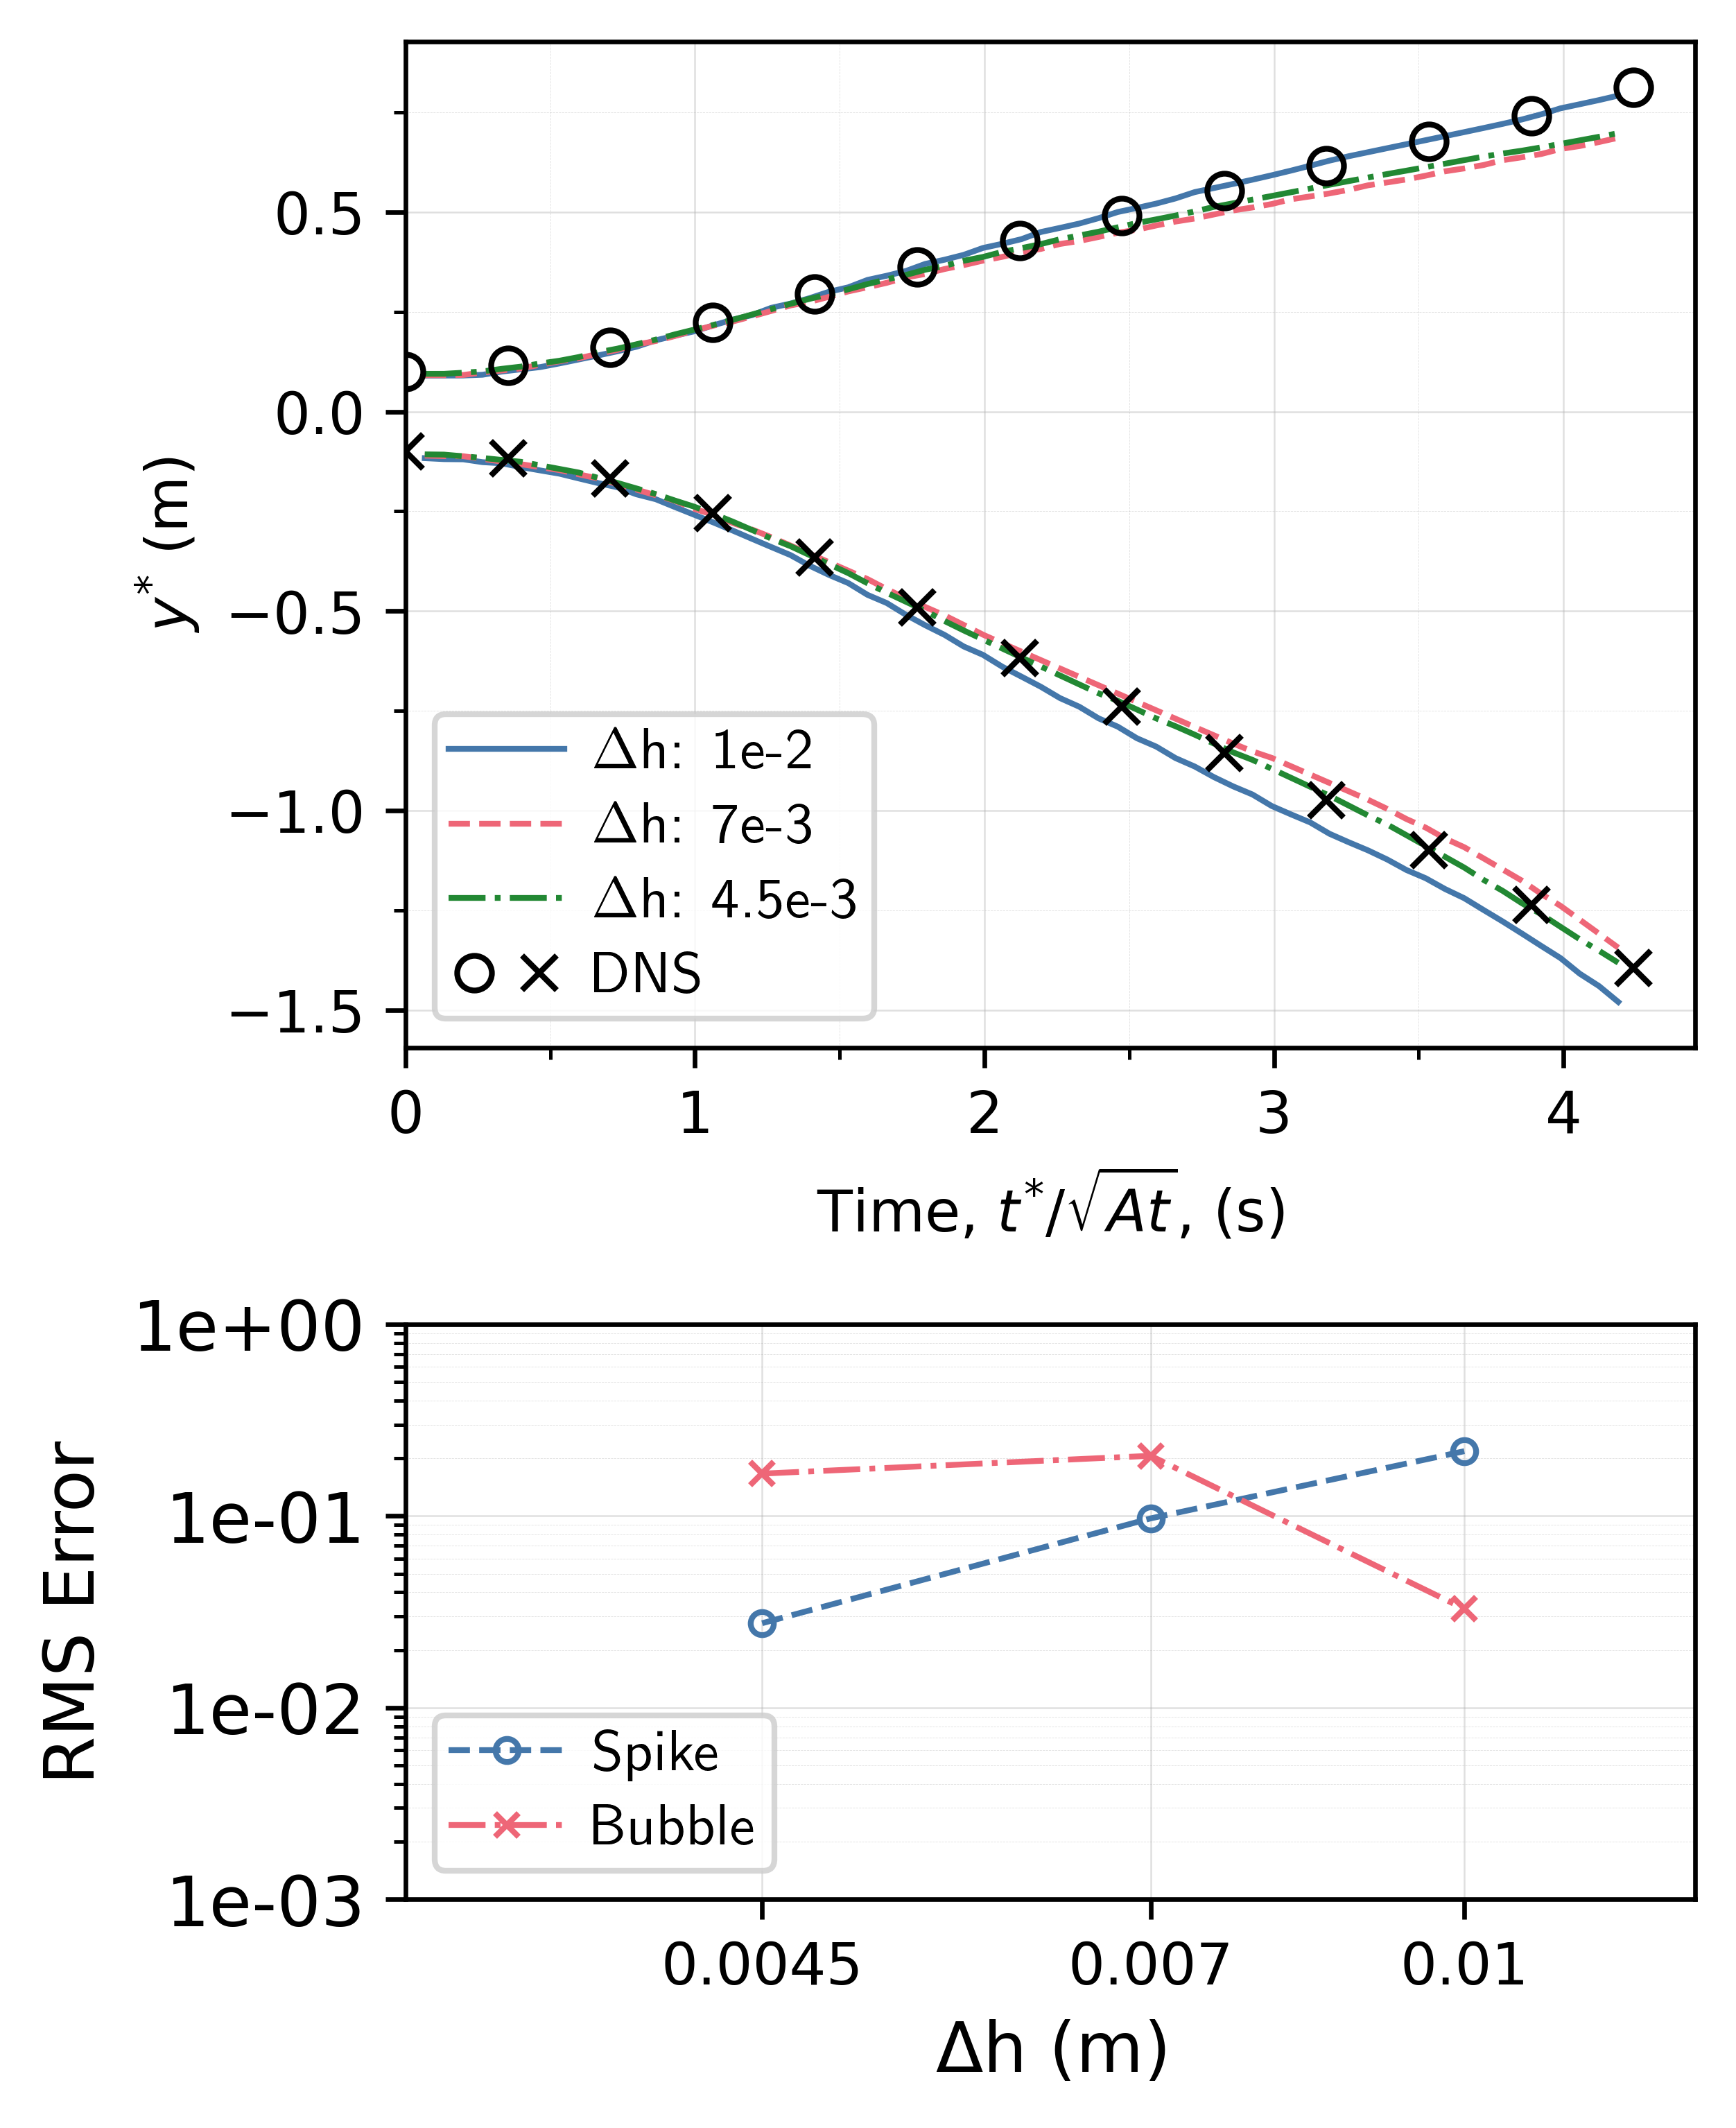

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.ticker import LogLocator, FormatStrFormatter
from itertools import cycle
from matplotlib.legend_handler import HandlerTuple
import scienceplots
import tol_colors           # NEW
import pandas as pd
# ---------------- paths & names ----------------
dir_list = [
    r"C:\Users\harsh\Desktop\pix\RT_evolution\re3000_at05_01",
    r'C:\Users\harsh\Desktop\pix\RT_evolution\re3000_at05_007',
    r"C:\Users\harsh\Desktop\pix\RT_evolution\re3000_at05_0045",
]
names    = ['1e-2', '7e-3', '4.5e-3']

name        = 'isosurface_table_'
name_append = '.csv'
ref_t       = lambda atwood_num: np.sqrt(atwood_num)

# ---------------- model & solver ----------------
model  = DynamicModel()
model.set_solver(RayleighTaylorSolver)
solver = model.solver

# ---------------- collect data ------------------
h_data = []
L2_data = []
Linf_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(path, name, name_append, name_vars, ref_t=ref_t)
    solver.calculate_stuff()

    cur = {'name'      : names[idx],
           'timesteps' : model.params['timesteps']}
    cur.update(model.analysis_data)   # y_bub, y_spike, …
    h_data.append(cur)

# ---------------- DNS reference -----------------
dns_df = pd.read_csv(
    r'C:\Users\harsh\Desktop\pix\RT_evolution\dns_compare_data\2D_Single-Mode_At0.5_Re3000_A0.05.csv'
)

# ---------------------------------------------------------------------------
# 0.  CREATE A SINGLE FIGURE WITH TWO ROWS
# ---------------------------------------------------------------------------
# Height ratios roughly reflect your old (4,3.5) and (4,2) sizes
fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2,
        figsize=(4, 5.8),     # 3.5 + 2  →  about 5.5–6 inches total
        dpi=600,
        gridspec_kw={"height_ratios": [3.5, 2], "hspace": 0.35}
)

# ---------------------------------------------------------------------------
# 1.  FIRST PLOT  (bubble / spike vs. time)  →  ax_top
# ---------------------------------------------------------------------------
with plt.style.context('science-modern'):
    plt.style.use(['high-vis'])          # only influences code in this block

    marks      = cycle(['o', 's', '^', 'd', 'v', 'x'])
    ls_cycler  = cycle(['-', '--', '-.', ':'])

    for idx, h in enumerate(h_data):
        mask = h['timesteps'] < dns_df['Time'].max()

        # bubble (solid)
        line_bub, = ax_top.plot(h['timesteps'][mask],
                                h['y_bub'][mask],
                                label=fr"$\Delta$h: {h['name']}",
                                linestyle=next(ls_cycler),
                                marker='')

        # spike (same colour, dashed)
        ax_top.plot(h['timesteps'][mask],
                    h['y_spike'][mask],
                    color=line_bub.get_color(),
                    linestyle=line_bub.get_linestyle(),
                    label="_nolegend_")

        # error bookkeeping – unchanged
        L2_err_spike,  Linf_err_spike  = solver.calc_errors(
                                            dns_df['Spike'],
                                            solver.interpolate_central_difference(
                                                h['y_spike'], h['timesteps'], dns_df['Time']))
        L2_err_bubble, Linf_err_bubble = solver.calc_errors(
                                            dns_df['Bubble'],
                                            solver.interpolate_central_difference(
                                                h['y_bub'],   h['timesteps'], dns_df['Time']))
        L2_data.append([L2_err_spike,  L2_err_bubble])
        Linf_data.append([np.max(Linf_err_spike), np.max(Linf_err_bubble)])

        h_data[idx].update(dict(
            L2spike   = L2_err_spike,
            L2bubble  = L2_err_bubble,
            Linfspike = Linf_err_spike,
            Linfbubble= Linf_err_bubble
        ))

    # DNS overlay
    dns_bub, = ax_top.plot(dns_df['Time'], dns_df['Bubble'], 'o',
                           color='black', markerfacecolor='none',
                           label='__nolegend_')
    dns_spk,  = ax_top.plot(dns_df['Time'], dns_df['Spike'],  'x',
                           color=dns_bub.get_color(), markerfacecolor='none',
                           label='__nolegend_')

    # axis formatting
    ax_top.set_xlim(0, None)
    ax_top.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax_top.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax_top.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax_top.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

    ax_top.set_xlabel(r"Time, $t^{*}/\sqrt{At}$, (s)")
    ax_top.set_ylabel(r"$y^{*}$ (m)")
    ax_top.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax_top.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 

    # Legend (DNS as combined entry)
    handles, labels = ax_top.get_legend_handles_labels()
    handles.append((dns_bub, dns_spk))
    labels.append('DNS')
    ax_top.legend(handles, labels,
                  handler_map={tuple: HandlerTuple(ndivide=None)},
                  loc='best', frameon=True, prop={'size': 10})

# ---------------------------------------------------------------------------
# 2.  SECOND PLOT  (RMS error vs. Δh)  →  ax_bot
# ---------------------------------------------------------------------------
x_vals = np.array([float(h['name'])     for h in h_data])
L2_s   = np.array([float(h['L2spike'])  for h in h_data])
L2_b   = np.array([float(h['L2bubble']) for h in h_data])

order       = np.argsort(x_vals)
x_vals      = x_vals[order]
y1_vals     = L2_s[order]
y2_vals     = L2_b[order]

with plt.style.context('science-modern'):
    plt.style.use(['muted'])             # only affects this lower axis

    ax_bot.plot(x_vals, y1_vals,
                linestyle='--', marker='o', markersize=4,
                markerfacecolor='none', linewidth=1, label='Spike')
    ax_bot.plot(x_vals, y2_vals,
                linestyle='-.', marker='x', markersize=4,
                markerfacecolor='none', linewidth=1, label='Bubble')

    # log scales
    ax_bot.set_xscale('log')
    ax_bot.set_yscale('log')
    ax_bot.set_xlim(3e-3, 1.3e-2)
    ax_bot.set_ylim(1e-3, 1)

    ax_bot.xaxis.set_major_locator(LogLocator(base=10, numticks=1))
    ax_bot.xaxis.set_minor_locator(LogLocator(base=10, numticks=10))
    ax_bot.xaxis.set_minor_formatter(FormatStrFormatter('%1.0e'))
    ax_bot.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
    ax_bot.yaxis.set_major_formatter(FormatStrFormatter('%1.0e'))

    # fixed tick labels at sorted Δh positions
    ax_bot.set_xticks(np.sort(x_vals))
    ax_bot.set_xticklabels([f'{v:.3}' for v in np.sort(x_vals)])
    plt.setp(ax_bot.get_xticklabels(), fontsize=10)
    plt.setp(ax_bot.get_yticklabels(), fontsize=12)
    # labels, grid, legend
    ax_bot.set_xlabel(r'$\Delta \text{h}$ (m)', fontsize=12)
    ax_bot.set_ylabel('RMS Error',       fontsize=12)
    ax_bot.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax_bot.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    ax_bot.legend(loc='best', frameon=True, prop={'size': 10})

# ---------------------------------------------------------------------------
# 3.  SHOW EVERYTHING
# ---------------------------------------------------------------------------
plt.show()

INFO: RayleighTaylorSolver: Analyse abgeschlossen.
INFO: Comparing model params with file params from params.ini ...
INFO: delta_h - file: 0.007, model: 0.05
INFO: amplitude - file: 0.1, model: 0.1
INFO: high_rho - file: 3, model: 3.0
INFO: low_rho - file: 1, model: 1.0
INFO: surface_tension - file: 1e-05, model: 1e-05
INFO: time_end - file: 6.5, model: 6.5
INFO: timestep - file: 0.0035, model: 0.0035
INFO: viscosity_high - file: 0.01, model: 0.01
INFO: viscosity_low - file: 0.01, model: 0.01
INFO: RayleighTaylorSolver: Analyse abgeschlossen.
INFO: Comparing model params with file params from params.ini ...
INFO: delta_h - file: 0.0045, model: 0.007
INFO: amplitude - file: 0.1, model: 0.1
INFO: high_rho - file: 3, model: 3.0
INFO: low_rho - file: 1, model: 1.0
INFO: surface_tension - file: 1e-05, model: 1e-05
INFO: time_end - file: 6.5, model: 6.5
INFO: timestep - file: 0.0035, model: 0.0035
INFO: viscosity_high - file: 0.01, model: 0.01
INFO: viscosity_low - file: 0.01, model: 0.01
IN

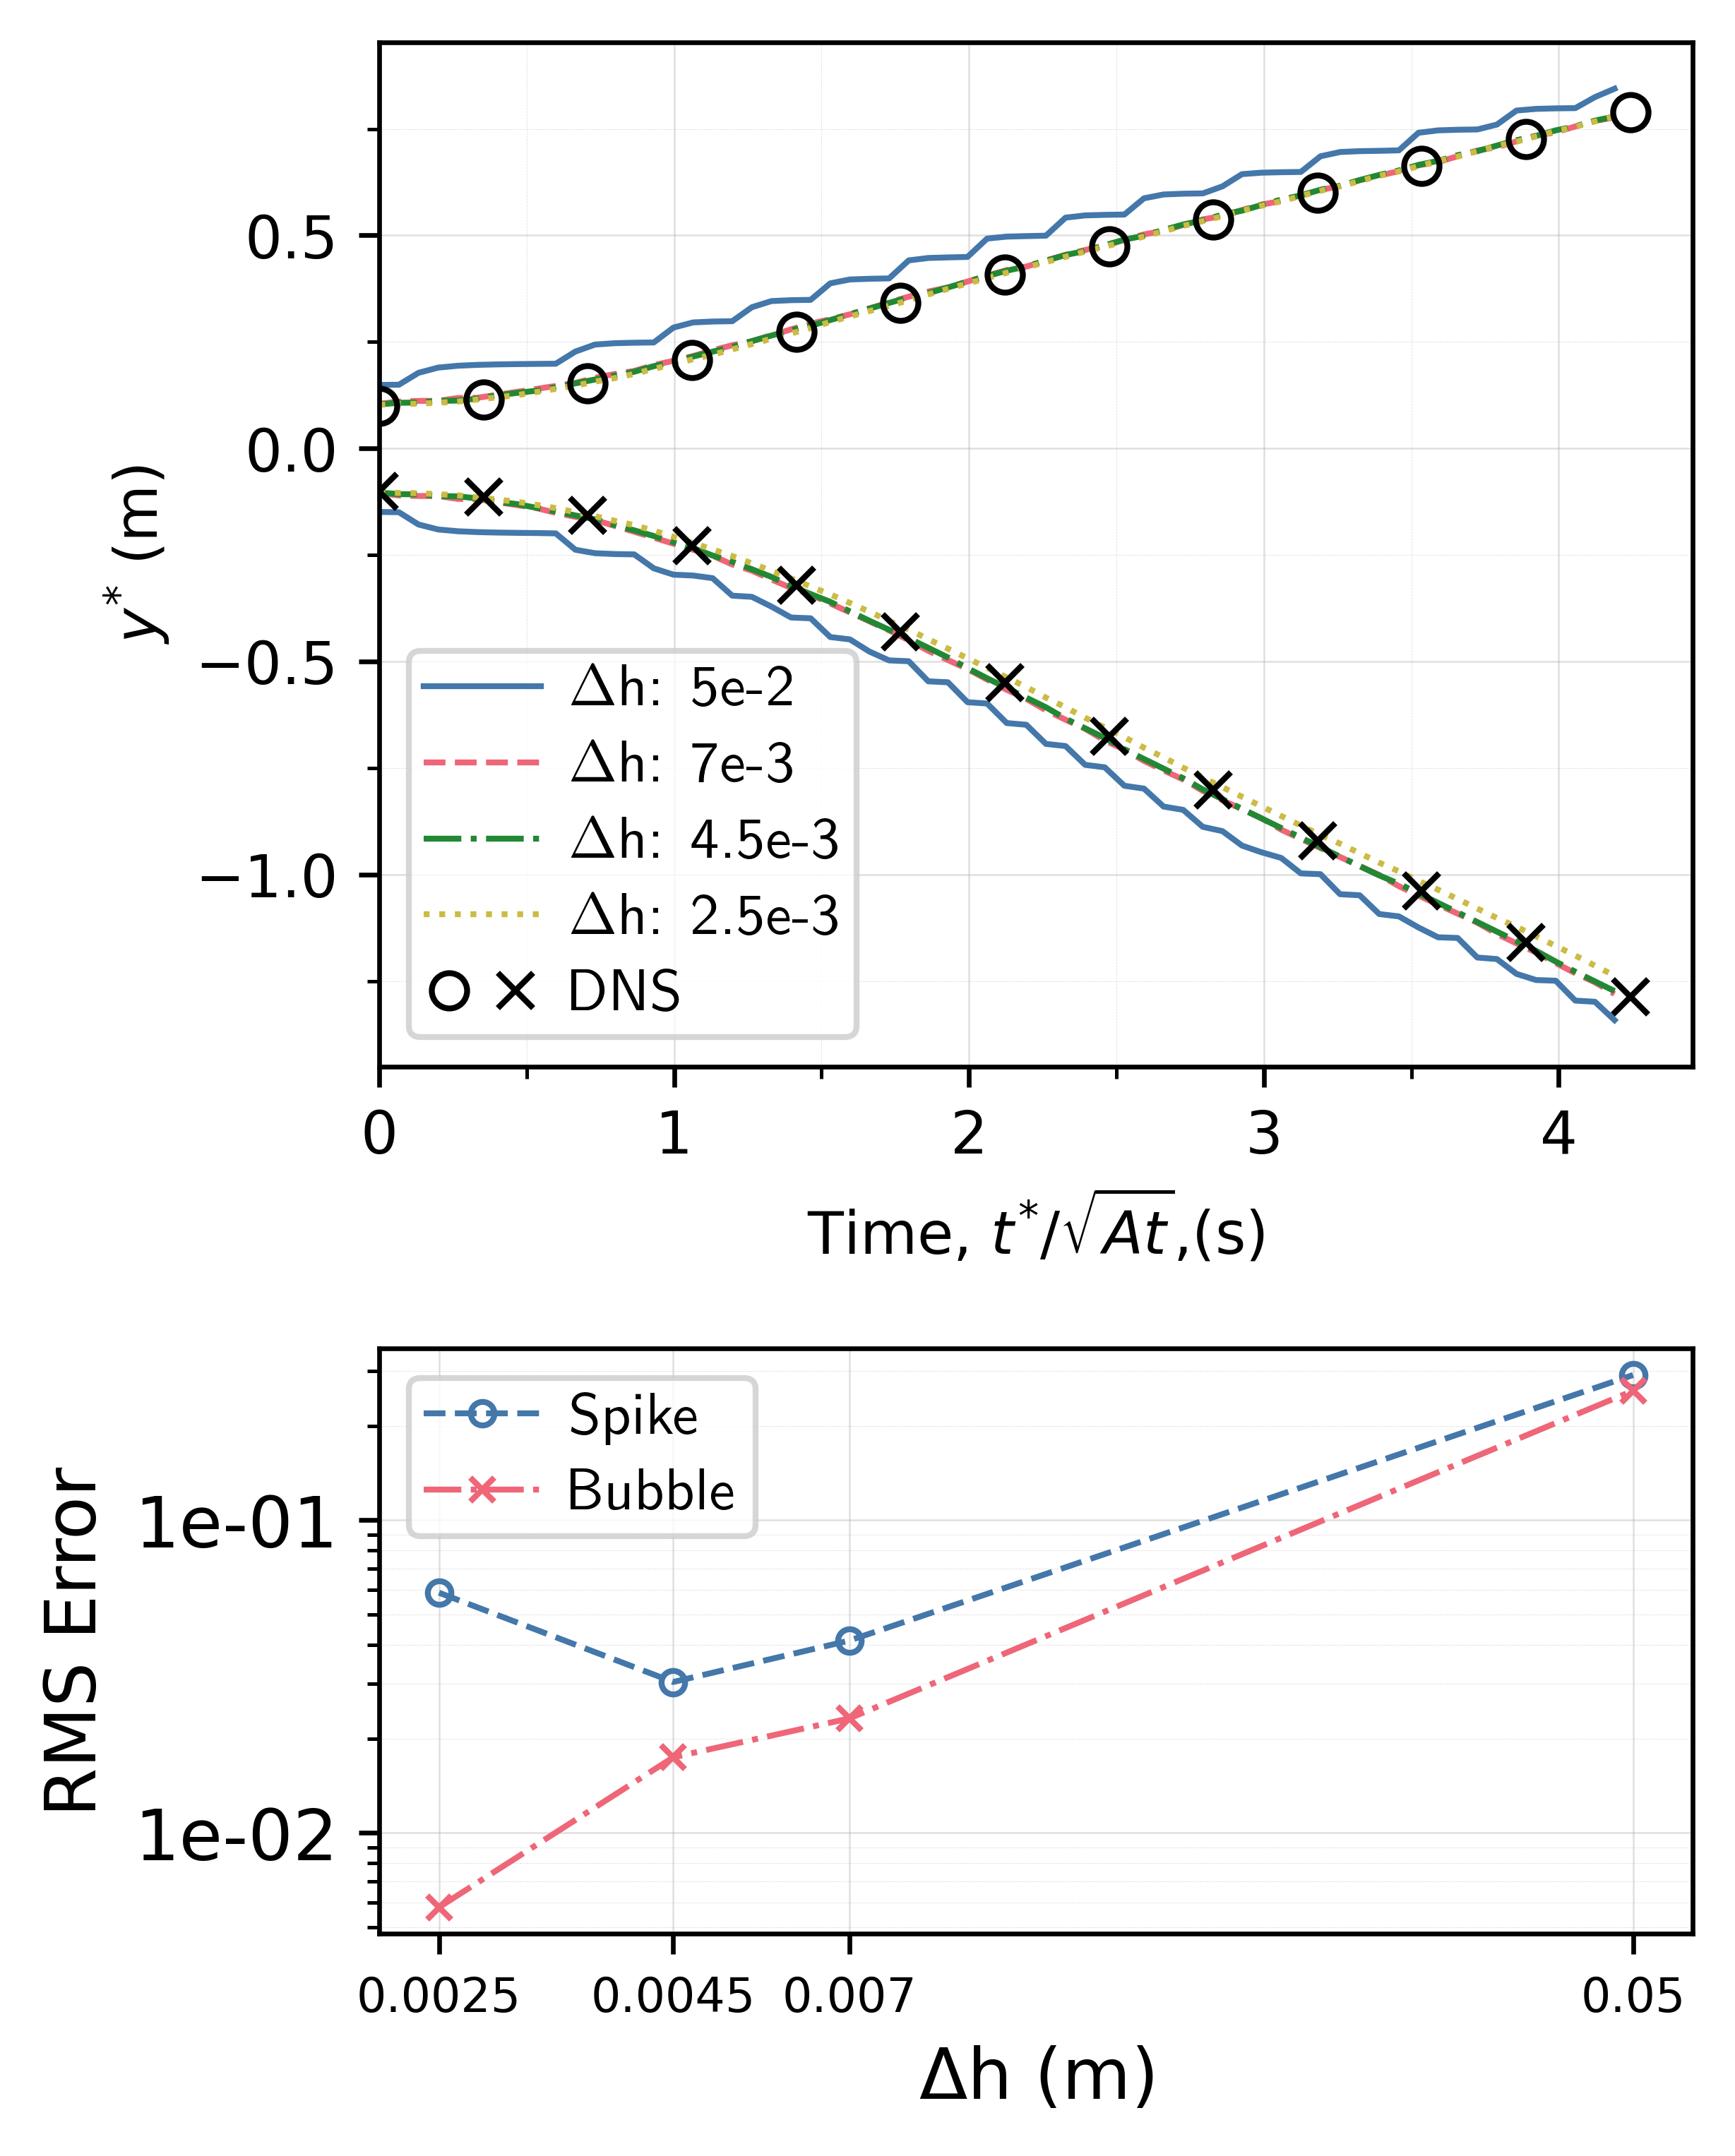

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.ticker import LogLocator, FormatStrFormatter
from itertools import cycle
from matplotlib.legend_handler import HandlerTuple
import scienceplots
import tol_colors           # NEW
import pandas as pd
# ---------------- paths & names ----------------
dir_list = [
    r"C:\Users\harsh\Desktop\pix\convergence\Re300_At0.5_sigma1e-05_dh0.05",
    r'C:\Users\harsh\Desktop\pix\convergence\Re300_At0.5_sigma1e-05_dh0.007',
    r"C:\Users\harsh\Desktop\pix\convergence\Re300_At0.5_sigma1e-05_dh0.0045",
    r"C:\Users\harsh\Desktop\pix\convergence\Re300_At0.5_sigma1e-05_dh0.0025",
]
names    = ['5e-2', '7e-3', '4.5e-3', '2.5e-3']

name        = 'isosurface_table_'
name_append = '.csv'
ref_t       = lambda atwood_num: np.sqrt(atwood_num)

# ---------------- model & solver ----------------
model  = DynamicModel()
model.set_solver(RayleighTaylorSolver)
solver = model.solver

# ---------------- collect data ------------------
h_data = []
L2_data = []
Linf_data = []
for idx, path in enumerate(dir_list):
    model.load_solution_data(path, name, name_append, name_vars, ref_t=ref_t)
    solver.calculate_stuff()

    cur = {'name'      : names[idx],
           'timesteps' : model.params['timesteps']}
    cur.update(model.analysis_data)   # y_bub, y_spike, …
    h_data.append(cur)

# ---------------- DNS reference -----------------
dns_df = pd.read_csv(
    r'C:\Users\harsh\Desktop\pix\RT_evolution\dns_compare_data\2D_Single-Mode_At0.5_Re300_A0.05.csv'
)

# ---------------------------------------------------------------------------
# 0.  CREATE A SINGLE FIGURE WITH TWO ROWS
# ---------------------------------------------------------------------------
# Height ratios roughly reflect your old (4,3.5) and (4,2) sizes
fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2,
        figsize=(4, 5.8),     # 3.5 + 2  →  about 5.5–6 inches total
        dpi=600,
        gridspec_kw={"height_ratios": [3.5, 2], "hspace": 0.35}
)

# ---------------------------------------------------------------------------
# 1.  FIRST PLOT  (bubble / spike vs. time)  →  ax_top
# ---------------------------------------------------------------------------
with plt.style.context('science-modern'):
    plt.style.use(['high-vis'])          # only influences code in this block

    marks      = cycle(['o', 's', '^', 'd', 'v', 'x'])
    ls_cycler  = cycle(['-', '--', '-.', ':'])

    for idx, h in enumerate(h_data):
        mask = h['timesteps'] < dns_df['Time'].max()

        # bubble (solid)
        line_bub, = ax_top.plot(h['timesteps'][mask],
                                h['y_bub'][mask],
                                label=fr"$\Delta$h: {h['name']}",
                                linestyle=next(ls_cycler),
                                marker='')

        # spike (same colour, dashed)
        ax_top.plot(h['timesteps'][mask],
                    h['y_spike'][mask],
                    color=line_bub.get_color(),
                    linestyle=line_bub.get_linestyle(),
                    label="_nolegend_")

        # error bookkeeping – unchanged
        L2_err_spike,  Linf_err_spike  = solver.calc_errors(
                                            dns_df['Spike'],
                                            solver.interpolate_central_difference(
                                                h['y_spike'], h['timesteps'], dns_df['Time']))
        L2_err_bubble, Linf_err_bubble = solver.calc_errors(
                                            dns_df['Bubble'],
                                            solver.interpolate_central_difference(
                                                h['y_bub'],   h['timesteps'], dns_df['Time']))
        L2_data.append([L2_err_spike,  L2_err_bubble])
        Linf_data.append([np.max(Linf_err_spike), np.max(Linf_err_bubble)])

        h_data[idx].update(dict(
            L2spike   = L2_err_spike,
            L2bubble  = L2_err_bubble,
            Linfspike = Linf_err_spike,
            Linfbubble= Linf_err_bubble
        ))

    # DNS overlay
    dns_bub, = ax_top.plot(dns_df['Time'], dns_df['Bubble'], 'o',
                           color='black', markerfacecolor='none',
                           label='__nolegend_')
    dns_spk,  = ax_top.plot(dns_df['Time'], dns_df['Spike'],  'x',
                           color=dns_bub.get_color(), markerfacecolor='none',
                           label='__nolegend_')

    # axis formatting
    ax_top.set_xlim(0, None)
    ax_top.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax_top.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax_top.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax_top.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

    ax_top.set_xlabel(r"Time, $t^{*}/\sqrt{At}$,(s)")
    ax_top.set_ylabel(r"$y^{*}$ (m)")
    ax_top.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax_top.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 

    # Legend (DNS as combined entry)
    handles, labels = ax_top.get_legend_handles_labels()
    handles.append((dns_bub, dns_spk))
    labels.append('DNS')
    ax_top.legend(handles, labels,
                  handler_map={tuple: HandlerTuple(ndivide=None)},
                  loc='best', frameon=True, prop={'size': 10})

# ---------------------------------------------------------------------------
# 2.  SECOND PLOT  (RMS error vs. Δh)  →  ax_bot
# ---------------------------------------------------------------------------
x_vals = np.array([float(h['name'])     for h in h_data])
L2_s   = np.array([float(h['L2spike'])  for h in h_data])
L2_b   = np.array([float(h['L2bubble']) for h in h_data])

order       = np.argsort(x_vals)
x_vals      = x_vals[order]
y1_vals     = L2_s[order]
y2_vals     = L2_b[order]

with plt.style.context('science-modern'):
    plt.style.use(['bright'])             # only affects this lower axis

    ax_bot.plot(x_vals, y1_vals,
                linestyle='--', marker='o', markersize=4,
                markerfacecolor='none', linewidth=1, label='Spike')
    ax_bot.plot(x_vals, y2_vals,
                linestyle='-.', marker='x', markersize=4,
                markerfacecolor='none', linewidth=1, label='Bubble')

    # log scales
    ax_bot.set_xscale('log')
    ax_bot.set_yscale('log')
    #ax_bot.set_xlim(3e-3, 1.3e-2)
    #ax_bot.set_ylim(1e-3, 1)

    ax_bot.xaxis.set_major_locator(ticker.NullLocator())
    ax_bot.xaxis.set_minor_locator(ticker.NullLocator())
    ax_bot.xaxis.set_minor_formatter(FormatStrFormatter('%1.0e'))
    ax_bot.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
    ax_bot.yaxis.set_major_formatter(FormatStrFormatter('%1.0e'))

    # fixed tick labels at sorted Δh positions
    ax_bot.set_xticks(np.sort(x_vals))
    ax_bot.set_xticklabels([f'{v:.4}' for v in np.sort(x_vals)])
    plt.setp(ax_bot.get_xticklabels(), fontsize=8)
    plt.setp(ax_bot.get_yticklabels(), fontsize=12)
    # labels, grid, legend
    ax_bot.set_xlabel(r'$\Delta \text{h}$ (m)', fontsize=12)
    ax_bot.set_ylabel('RMS Error',       fontsize=12)
    ax_bot.grid(which='minor', linestyle='--', linewidth=0.1, alpha=0.4)  # minor grid
    ax_bot.grid(which='major', linestyle='-',  linewidth=0.3, alpha=0.4) 
    ax_bot.legend(loc='best', frameon=True, prop={'size': 10})

# ---------------------------------------------------------------------------
# 3.  SHOW EVERYTHING
# ---------------------------------------------------------------------------
plt.show()

In [8]:
# %% ###############################################################
######################## Reynolds Number #########################
####################################################################
import scienceplots
dir_list = [
    #r'C:/Users/harsh/Desktop/pix',
    #r"C:\Users\harsh\Desktop\pix\Re300_At0.2_sigma1e-05_dh0.0045",
    #r'C:\Users\harsh\Desktop\pix\RT_evolution\re300_at05',
    #r"D:\thesis\HARD_DATA\RAYLEIGH_TAYLOR\VOF\re300_at05_noTURB",
    #r"D:\thesis\HARD_DATA\RAYLEIGH_TAYLOR\2Fluid\twoF_finest",
    #r"C:\Users\harsh\Desktop\pix\RT_evolution\Re3000_At0.2_sigma1e-05_dh0.0045",
    r"C:\Users\harsh\Desktop\pix\RT_evolution\re3000_at05_0045",
    r"D:\thesis\HARD_DATA\RAYLEIGH_TAYLOR\2Fluid\twoF_start2"
]
name = 'isosurface_table_'
name_append = '.csv'
#if reference time is different from the reference time initially set
#ref_t = lambda atwood_num: np.sqrt(atwood_num)
#model.load_solution_data(dir, name, name_append, name_vars, ref_t= ref_t)
#model.calculate_stuff()

names = ['Re300_At0.2', 'Re300_At0.5', 'Re1000_At0.2', 'Re1000_At0.5', 'Re3000_At0.2', 'Re3000_At0.5']
nondim = [np.sqrt(0.5), np.sqrt(0.5), np.sqrt(0.2), np.sqrt(0.5), np.sqrt(0.2), np.sqrt(0.5)]
h_data = []
for idx, path in enumerate(dir_list):
    at = nondim[idx]
    ref_t = lambda at: np.sqrt(at)
    model.load_solution_data(path, name, name_append, name_vars, ref_t= ref_t)
    model.solver.calculate_stuff()
    cur_h_data = {}
    cur_h_data['name'] = names[idx]
    cur_h_data['timesteps'] = model.params['timesteps']
    cur_h_data['nondim'] = nondim[idx]
    cur_h_data.update(model.analysis_data)
    h_data.append(cur_h_data)
#----------------------------------------------------
dns_df = pd.read_csv(
    r"C:\Users\harsh\Desktop\pix\RT_evolution\dns_compare_data\2D_Single-Mode_At0.5_Re3000_A0.05.csv"
)
#----------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scienceplots
import tol_colors
from itertools import cycle
with plt.style.context('science-modern'):
    plt.style.use(['vibrant'])
    marks = cycle(['o', 's', '^', 'd', 'v', 'x'])
    ls_cycler = cycle(['--', '-.'])
    fig, ax = plt.subplots(figsize=(20,15), dpi=600)
    L2_data = []
    Linf_data = []
    for h in h_data:
        t_scaled = h['timesteps']# /  h['nondim']        # <── scale once
        mask     = t_scaled < (dns_df['Time'].max())

        # bubble
        line_bub, = ax.plot(t_scaled[mask],
                            h['y_bub'][mask],
                            label=h['name'],           # already contains Re & At
                            linestyle=next(ls_cycler))

        # spike (same colour)
        ax.plot(t_scaled[mask],
                h['y_spike'][mask],
                color=line_bub.get_color(),
                linestyle=line_bub.get_linestyle(),
                label="_nolegend_")
    dns_bub, = ax.plot(dns_df['Time'], dns_df['Bubble'], 'o',
                           color='black', markerfacecolor='none',
                           label='__nolegend_')
    dns_spk,  = ax.plot(dns_df['Time'], dns_df['Spike'],  'x',
                           color=dns_bub.get_color(), markerfacecolor='none',
                           label='__nolegend_')
    #ax.set_ylim(-2, 1.0)
    ax.set_xlim(0, None)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

    label_font = {'fontsize': 12}#, 'fontfamily': 'Arial'}
    ax.set_xlabel(r"Time (s)" , **label_font)
    ax.set_ylabel(r"$y*$ (m)", **label_font)

    legend_box = ax.legend(
        frameon=True,
        #prop={'family': 'Arial', 'size': 10},
        loc = "lower left"
    )
    ax.grid(which='minor', linestyle='--', linewidth=0.2, alpha=0.5)  # minor grid
    ax.grid(which='major', linestyle='-',  linewidth=0.5, alpha=0.5) 
#ax.grid(True)
    plt.show()


INFO: Comparing model params with file params from params.ini ...
INFO: delta_h - file: 0.0045, model: 0.0045
INFO: amplitude - file: 0.1, model: 0.1
INFO: high_rho - file: 3, model: 3.0
INFO: low_rho - file: 1, model: 1.0
INFO: surface_tension - file: 1e-05, model: 1e-05
INFO: time_end - file: 5.0, model: 5.0
INFO: timestep - file: 0.0035, model: 0.0035
INFO: viscosity_high - file: 0.001, model: 0.001
INFO: viscosity_low - file: 0.001, model: 0.001
INFO: RayleighTaylorSolver: Analyse abgeschlossen.
INFO: Comparing model params with file params from params.ini ...
INFO: amplitude - file: 0.1, model: 0.1
INFO: high_rho - file: 3, model: 3.0
INFO: low_rho - file: 1, model: 1.0
INFO: surface_tension - file: 1e-05, model: 1e-05
INFO: time_end - file: 5.5, model: 5.0
INFO: timestep - file: 0.0035, model: 0.0035
INFO: viscosity_high - file: 0.001, model: 0.001
INFO: viscosity_low - file: 0.001, model: 0.001
INFO: RayleighTaylorSolver: Analyse abgeschlossen.
